# Alpha phase estimation using ETP

In [1]:
import sys
import numpy as np
import scipy.signal as signal

sys.path.append("../../..")

from EEGPhasePy.estimators import ETP

Generate the simulated training and testing EEG data

In [2]:
fs = 2000
time_data = np.arange(0, 200, 1/fs)

training_signal_clean = np.sin(2 * np.pi * 10 * time_data)
training_signal = training_signal_clean + np.random.normal(0, 2, len(time_data))

testing_signal_clean = np.sin(2 * np.pi * 10 * time_data)
testing_signal = testing_signal_clean + np.random.normal(0, 2, len(time_data))

Define the real-time and ground-truth alpha bandpass filters. 

The real-time filter should be lower order since it will be applied to a window with fewer samples than the ground truth filter. The ground truth filter is what will be used to extract the phase for phase stats (i.e. accuracy, mean and std of phase) as well as to generate the polar histogram and trigger waveform plots

In [3]:
rt_filter = signal.firwin(120, [8, 12], fs=fs, pass_zero=False)
gt_filter = signal.firwin(300, [8, 12], fs=fs, pass_zero=False)

Construct the ETP class and fit it to the training data. We will use the default edge and window length for this example

*A note on window length and edge effects:*

When looking at other frequency bands that have more phase instability (as is the case with theta) or in cases of lower SNR, such as extracting phase data from the leisoned cortex of stroke patients, adjusting the window length and edge removed can significantly improve ETP performance. By increasing window length, more data is included in the sliding window allowing for a higher order filter to be used. This will help to more effectively extract the "signal" from "noise". However, increasing filter order will also increase the amount of data that is effected by filtering. Thus, you will need to increase the amount of signal removed from the edge of the window to compensate. This can potentially compromise ETP performance. It is important to balance all 3 of these factors

In [4]:
etp = ETP(rt_filter, gt_filter, fs)
etp.fit(training_signal, min_ipi=int(fs * 1/12))

Now that ETP has estimated the optimal `Tadj` (inter-peak-interval), we can run pseudo-real-time simulations on the testing data

All estimators in EEGPhasePy contain a `predict` method that takes the unfiltered sliding window data as an argument. `predict` filters the data with the provided real-time filter and removes the specified edge from the data. Across estimators the functionality and output can differ. With ETP, the `predict` method will output how much time from the moment `predict` was called, must pass before the target phase will occur. You can use this information to schedule your phase-triggered stimulus.

In our psuedo-real-time simulations we will store the sample at which our target phase was predicted to occur so that we can quantify and visualize the performance of ETP

In [5]:
window_i = 2*fs
window_len = int(0.5*fs)
window_step = int(0.06*fs) # using a step of 60 ms

triggers = []

while window_i + window_len < len(testing_signal):
    window = testing_signal[window_i:window_i + window_len]
    
    if window_i + window_len + etp.predict(window, 0) < len(testing_signal) - window_len:
        triggers.append(window_i + window_len + etp.predict(window, 0))
    window_i += window_step

Mean phase: 1.5371571066620542
Std phase: 2.655849279617015
Accuracy: 99.99873971880933


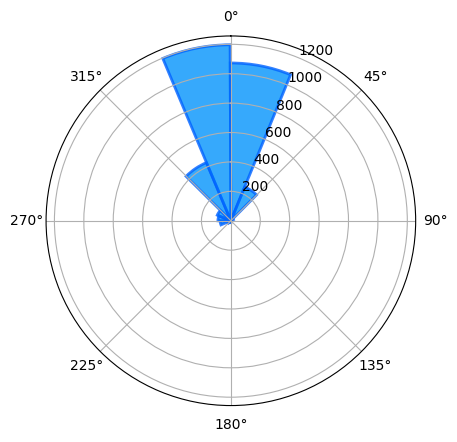

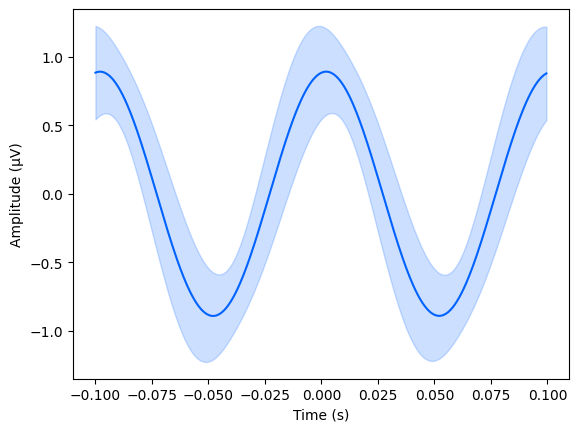

In [10]:
polar_hist_fig = etp.polar_histogram_from_triggers(testing_signal, triggers)
waveform_fig = etp.plot_mean_std_waveform_from_triggers(testing_signal, triggers, tmin=0.1, tmax=0.1)

phase_standard_deviation = etp.std_phase_from_triggers(testing_signal, triggers, degree=True)
phase_mean = etp.mean_phase_from_triggers(testing_signal, triggers, degree=True)
accuracy = etp.phase_accuracy_from_triggers(testing_signal, triggers, 0)

print("Mean phase: " + str(phase_mean))
print("Std phase: " + str(phase_standard_deviation))
print("Accuracy: " + str(100*accuracy))

Above, we estimated peaks using ETP. However, with ETP you can easily estimate any other phase by changing the `target_phase` argument to the desired phase in radians. Below we estimate alpha rising phase by simply changing `target_phase` to $3\pi/2$

Mean phase: 4.181173535821733
Std phase: 2.808168156074827
Accuracy: 99.98514219269397


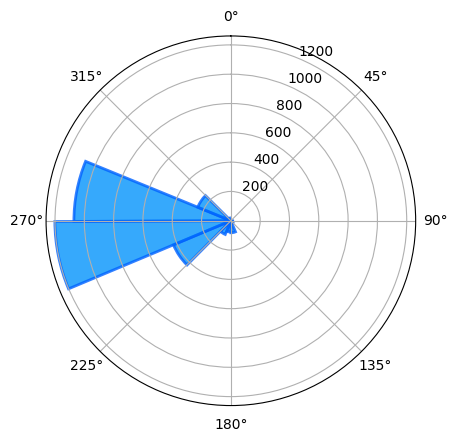

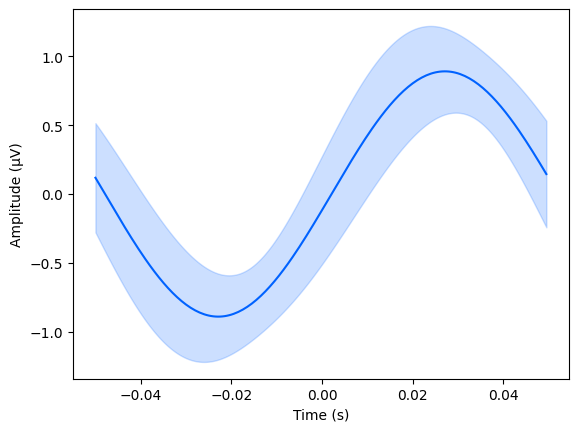

In [11]:
window_i = 2*fs
window_len = int(0.5*fs)
window_step = int(0.06*fs) # using a step of 60 ms

triggers = []

while window_i + window_len < len(testing_signal):
    window = testing_signal[window_i:window_i + window_len]
    
    if window_i + window_len + etp.predict(window, 0) < len(testing_signal) - 2*window_len:
        triggers.append(window_i + window_len + etp.predict(window, (3/2)*np.pi))
    window_i += window_step

polar_hist_fig = etp.polar_histogram_from_triggers(testing_signal, triggers)
waveform_fig = etp.plot_mean_std_waveform_from_triggers(testing_signal, triggers, tmin=0.05, tmax=0.05)

phase_standard_deviation = etp.std_phase_from_triggers(testing_signal, triggers, degree=True)
phase_mean = etp.mean_phase_from_triggers(testing_signal, triggers, degree=True)
accuracy = etp.phase_accuracy_from_triggers(testing_signal, triggers, 270)

print("Mean phase: " + str(phase_mean))
print("Std phase: " + str(phase_standard_deviation))
print("Accuracy: " + str(100*accuracy))

Similarly, to target troughs, instead of peaks, we just change the `target_phase` to $`\pi`$

Mean phase: 4.499950678199643
Std phase: 2.4853691228458055
Accuracy: 99.98966785543823


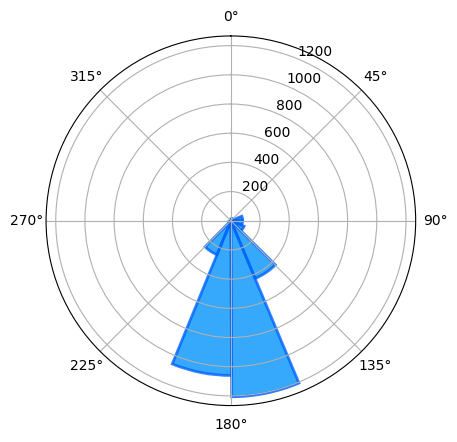

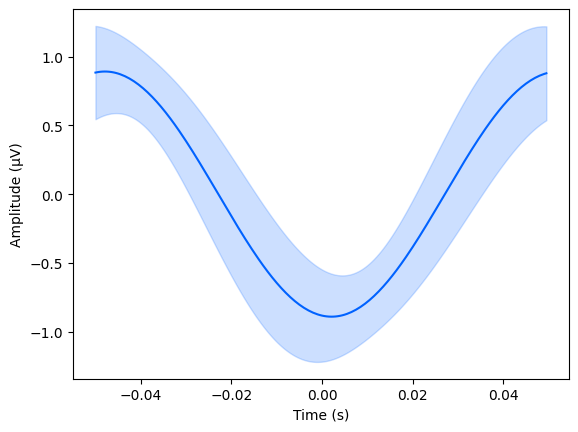

In [12]:
window_i = 2*fs
window_len = int(0.5*fs)
window_step = int(0.06*fs) # using a step of 60 ms

triggers = []

while window_i + window_len < len(testing_signal):
    window = testing_signal[window_i:window_i + window_len]
    
    if window_i + window_len + etp.predict(window, 0) < len(testing_signal) - 2*window_len:
        triggers.append(window_i + window_len + etp.predict(window, np.pi))
    window_i += window_step

polar_hist_fig = etp.polar_histogram_from_triggers(testing_signal, triggers)
waveform_fig = etp.plot_mean_std_waveform_from_triggers(testing_signal, triggers, tmin=0.05, tmax=0.05)

phase_standard_deviation = etp.std_phase_from_triggers(testing_signal, triggers, degree=True)
phase_mean = etp.mean_phase_from_triggers(testing_signal, triggers, degree=True)
accuracy = etp.phase_accuracy_from_triggers(testing_signal, triggers, 180)

print("Mean phase: " + str(phase_mean))
print("Std phase: " + str(phase_standard_deviation))
print("Accuracy: " + str(100*accuracy))